In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch import optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv('/Users/bisakhpatra/Desktop/PyTorch/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


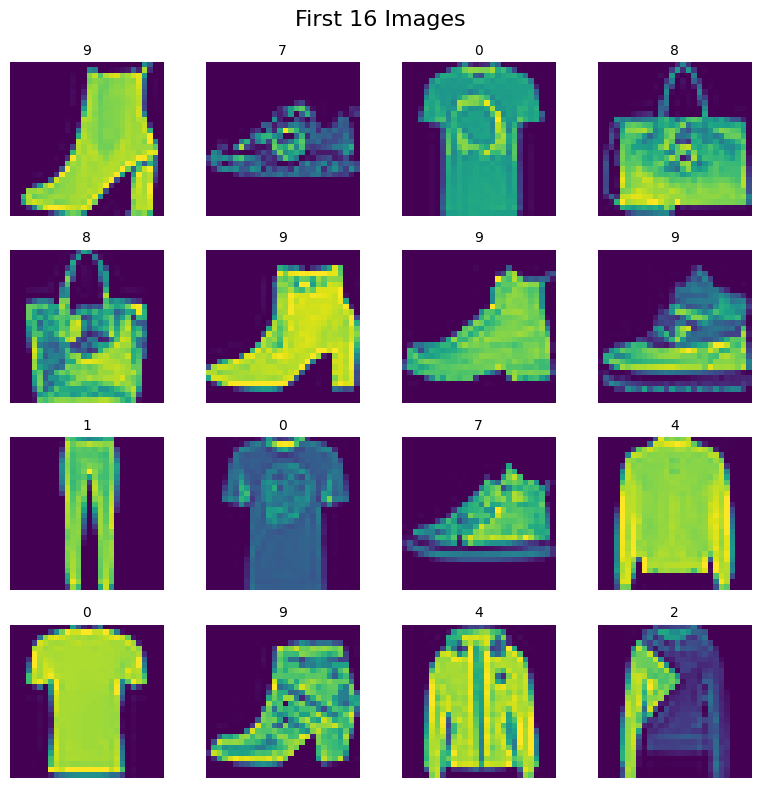

In [6]:
import numpy as np

# If your CSV has labels in the first column and 784 pixels afterward:
imgs = df.iloc[:16, 1:].values
labels = df.iloc[:16, 0].values

imgs = imgs.reshape(-1, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("First 16 Images", fontsize=16)
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[idx], cmap="viridis")
    ax.axis("off")
    ax.set_title(str(labels[idx]), fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [9]:
y

array([9, 7, 0, ..., 8, 4, 8])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train = X_train/255.0
X_test = X_test/255.0

In [12]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [13]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [16]:
train_dataset[1]

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00392157,
        0.        , 0.        , 0.38431373, 0.37647059, 0.39215686,
        0.38039216, 0.31764706, 0.        , 0.        , 0.00784314,
        0.00784314, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00392157,
        0.00392157, 0.        , 0.        , 0.        , 0.02745098,
        0.8627451 , 0.70588235, 0.61960784, 0.64705882, 0.81568627,
        0.02745098, 0.        , 0.        , 0.        , 0.        ,
        0.00392157, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00392157, 0.        , 0.        , 0.        ,
        0.02745098, 0.35294118, 0.70980392, 0.55294118, 0.71372549,
        0.89803922, 0.71372549, 0.64705882, 0.77

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
batch = next(iter(train_loader))
batch

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64),
 tensor([4, 7, 9, 9, 2, 8, 5, 9, 3, 4, 2, 2, 4, 7, 7, 9, 9, 3, 3, 7, 9, 4, 0, 3,
         0, 8, 1, 6, 2, 8, 8, 1])]

In [23]:
class MyANN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [24]:
epochs = 100
learning_rate = 0.1

In [25]:
model = MyANN(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [26]:
len(train_loader)

150

In [28]:
for epoch in range(epochs):
    total_loss = 0
    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features.float())
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_loss:.2f}')

Epoch: 1, Loss: 1.31
Epoch: 2, Loss: 0.78
Epoch: 3, Loss: 0.66
Epoch: 4, Loss: 0.60
Epoch: 5, Loss: 0.53
Epoch: 6, Loss: 0.50
Epoch: 7, Loss: 0.47
Epoch: 8, Loss: 0.45
Epoch: 9, Loss: 0.43
Epoch: 10, Loss: 0.41
Epoch: 11, Loss: 0.39
Epoch: 12, Loss: 0.36
Epoch: 13, Loss: 0.35
Epoch: 14, Loss: 0.34
Epoch: 15, Loss: 0.32
Epoch: 16, Loss: 0.32
Epoch: 17, Loss: 0.30
Epoch: 18, Loss: 0.31
Epoch: 19, Loss: 0.27
Epoch: 20, Loss: 0.27
Epoch: 21, Loss: 0.25
Epoch: 22, Loss: 0.24
Epoch: 23, Loss: 0.24
Epoch: 24, Loss: 0.24
Epoch: 25, Loss: 0.23
Epoch: 26, Loss: 0.20
Epoch: 27, Loss: 0.21
Epoch: 28, Loss: 0.21
Epoch: 29, Loss: 0.20
Epoch: 30, Loss: 0.19
Epoch: 31, Loss: 0.19
Epoch: 32, Loss: 0.17
Epoch: 33, Loss: 0.17
Epoch: 34, Loss: 0.17
Epoch: 35, Loss: 0.16
Epoch: 36, Loss: 0.16
Epoch: 37, Loss: 0.17
Epoch: 38, Loss: 0.16
Epoch: 39, Loss: 0.14
Epoch: 40, Loss: 0.14
Epoch: 41, Loss: 0.13
Epoch: 42, Loss: 0.12
Epoch: 43, Loss: 0.12
Epoch: 44, Loss: 0.13
Epoch: 45, Loss: 0.12
Epoch: 46, Loss: 0.

In [29]:
model.eval()

MyANN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [30]:
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features.float())
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()
    
    print(f'Accuracy: {correct/total:.2f}')

Accuracy: 0.83
